# ============================================================
# ALEXNET AND VGG16 FROM SCRATCH
# ============================================================

In [ ]:
!pip install torch torchvision scikit-learn -q

In [ ]:
# =========================
# IMPORT LIBRARIES
# =========================

import os
import copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

In [ ]:
# =========================
# DEVICE CONFIGURATION
# =========================

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Using Device:", device)

Using Device: cuda


In [ ]:
# ============================================================
# CONNECT GOOGLE DRIVE
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ============================================================
# DATASET PATH
# ============================================================

DATASET_PATH = "/content/drive/MyDrive/dataset/cats_and_dogs_small"

train_dir = os.path.join(DATASET_PATH, "train")
val_dir = os.path.join(DATASET_PATH, "validation")
test_dir = os.path.join(DATASET_PATH, "test")

In [ ]:
# ============================================================
# IMAGE TRANSFORMS
# ============================================================

train_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(15),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

val_test_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

In [ ]:
# ============================================================
# LOAD DATASETS
# ============================================================

train_dataset = datasets.ImageFolder(
    train_dir,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    val_dir,
    transform=val_test_transform
)

test_dataset = datasets.ImageFolder(
    test_dir,
    transform=val_test_transform
)

print("Classes:", train_dataset.classes)

Classes: ['cats', 'dogs']


In [ ]:
# ============================================================
# DATALOADERS
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [ ]:
# ============================================================
# ALEXNET FROM SCRATCH
# ============================================================

class AlexNetScratch(nn.Module):

    def __init__(self, num_classes=2):

        super(AlexNetScratch, self).__init__()

        self.features = nn.Sequential(

    nn.Conv2d(
        3, 64,
        kernel_size=11,
        stride=4,
        padding=2
    ),

    nn.BatchNorm2d(64),

    nn.ReLU(inplace=True),

    nn.MaxPool2d(
        kernel_size=3,
        stride=2
    ),

    nn.Conv2d(
        64, 192,
        kernel_size=5,
        padding=2
    ),

    nn.BatchNorm2d(192),

    nn.ReLU(inplace=True),

    nn.MaxPool2d(
        kernel_size=3,
        stride=2
    ),

    nn.Conv2d(
        192, 384,
        kernel_size=3,
        padding=1
    ),

    nn.BatchNorm2d(384),

    nn.ReLU(inplace=True),

    nn.Conv2d(
        384, 256,
        kernel_size=3,
        padding=1
    ),

    nn.BatchNorm2d(256),

    nn.ReLU(inplace=True),

    nn.Conv2d(
        256, 256,
        kernel_size=3,
        padding=1
    ),

    nn.BatchNorm2d(256),

    nn.ReLU(inplace=True),

    nn.MaxPool2d(
        kernel_size=3,
        stride=2
    )
)

        self.classifier = nn.Sequential(

            nn.Dropout(0.5),

            nn.Linear(
                256 * 6 * 6,
                4096
            ),

            nn.ReLU(inplace=True),

            nn.Dropout(0.5),

            nn.Linear(
                4096,
                4096
            ),

            nn.ReLU(inplace=True),

            nn.Linear(
                4096,
                num_classes
            )
        )

    def forward(self, x):

        x = self.features(x)

        x = torch.flatten(x, 1)

        x = self.classifier(x)

        return x

In [ ]:
# ============================================================
# VGG16 FROM SCRATCH
# ============================================================

class VGG16Scratch(nn.Module):

    def __init__(self, num_classes=2):

        super(VGG16Scratch, self).__init__()

        self.features = nn.Sequential(

    # BLOCK 1
    nn.Conv2d(3,64,3,padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(inplace=True),

    nn.Conv2d(64,64,3,padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(inplace=True),

    nn.MaxPool2d(2,2),

    # BLOCK 2
    nn.Conv2d(64,128,3,padding=1),
    nn.BatchNorm2d(128),
    nn.ReLU(inplace=True),

    nn.Conv2d(128,128,3,padding=1),
    nn.BatchNorm2d(128),
    nn.ReLU(inplace=True),

    nn.MaxPool2d(2,2),

    # BLOCK 3
    nn.Conv2d(128,256,3,padding=1),
    nn.BatchNorm2d(256),
    nn.ReLU(inplace=True),

    nn.Conv2d(256,256,3,padding=1),
    nn.BatchNorm2d(256),
    nn.ReLU(inplace=True),

    nn.Conv2d(256,256,3,padding=1),
    nn.BatchNorm2d(256),
    nn.ReLU(inplace=True),

    nn.MaxPool2d(2,2),

    # BLOCK 4
    nn.Conv2d(256,512,3,padding=1),
    nn.BatchNorm2d(512),
    nn.ReLU(inplace=True),

    nn.Conv2d(512,512,3,padding=1),
    nn.BatchNorm2d(512),
    nn.ReLU(inplace=True),

    nn.Conv2d(512,512,3,padding=1),
    nn.BatchNorm2d(512),
    nn.ReLU(inplace=True),

    nn.MaxPool2d(2,2),

    # BLOCK 5
    nn.Conv2d(512,512,3,padding=1),
    nn.BatchNorm2d(512),
    nn.ReLU(inplace=True),

    nn.Conv2d(512,512,3,padding=1),
    nn.BatchNorm2d(512),
    nn.ReLU(inplace=True),

    nn.Conv2d(512,512,3,padding=1),
    nn.BatchNorm2d(512),
    nn.ReLU(inplace=True),

    nn.MaxPool2d(2,2)
)

        self.classifier = nn.Sequential(

            nn.Linear(
                512 * 7 * 7,
                4096
            ),

            nn.ReLU(True),

            nn.Dropout(0.5),

            nn.Linear(
                4096,
                4096
            ),

            nn.ReLU(True),

            nn.Dropout(0.5),

            nn.Linear(
                4096,
                num_classes
            )
        )

    def forward(self, x):

        x = self.features(x)

        x = torch.flatten(x,1)

        x = self.classifier(x)

        return x


In [ ]:
# ============================================================
# TRAINING FUNCTION
# ============================================================

def train_model(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        scheduler,
        epochs=50
):

    best_acc = 0.0

    train_acc_history = []
    val_acc_history = []

    for epoch in range(epochs):

        print(f"\nEpoch {epoch+1}/{epochs}")
        print("="*50)

        # TRAINING
        model.train()

        running_loss = 0.0
        running_corrects = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            _, preds = torch.max(outputs,1)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            running_corrects += (
                preds == labels
            ).sum().item()

            total += labels.size(0)

        train_acc = (
            running_corrects / total
        ) * 100

        train_acc_history.append(train_acc)

        # VALIDATION
        model.eval()

        val_corrects = 0
        val_total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                _, preds = torch.max(outputs,1)

                val_corrects += (
                    preds == labels
                ).sum().item()

                val_total += labels.size(0)

        val_acc = (
            val_corrects / val_total
        ) * 100

        val_acc_history.append(val_acc)

        scheduler.step()

        print(f"Loss: {running_loss:.4f}")

        print(f"Train Accuracy: {train_acc:.2f}%")

        print(f"Validation Accuracy: {val_acc:.2f}%")

    return train_acc_history, val_acc_history

In [ ]:
# ============================================================
# EVALUATION FUNCTION
# ============================================================

def evaluate_model(model, test_loader):

    model.eval()

    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs,1)

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

            all_preds.extend(
                predicted.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

    accuracy = 100 * correct / total

    print(f"\nTest Accuracy: {accuracy:.2f}%")

    print("\nClassification Report:\n")

    print(
        classification_report(
            all_labels,
            all_preds,
            target_names=['Cat','Dog']
        )
    )

    cm = confusion_matrix(
        all_labels,
        all_preds
    )

    plt.figure(figsize=(6,6))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Cat','Dog'],
        yticklabels=['Cat','Dog']
    )

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.title("Confusion Matrix")

    plt.show()

    return accuracy

In [ ]:
# ============================================================
# INITIALIZE ALEXNET
# ============================================================

def initialize_weights(model):

    for m in model.modules():

        if isinstance(m, nn.Conv2d):

            nn.init.kaiming_normal_(m.weight)

        elif isinstance(m, nn.Linear):

            nn.init.xavier_normal_(m.weight)


alexnet = AlexNetScratch().to(device)
initialize_weights(alexnet)
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    alexnet.parameters(),
    lr=0.00005
)

In [ ]:
# ============================================================
# TRAIN ALEXNET
# ============================================================

print("\nTRAINING ALEXNET FROM SCRATCH")

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.5
)

alex_train_acc, alex_val_acc = train_model(

    alexnet,

    train_loader,

    val_loader,

    criterion,

    optimizer,

    scheduler,

    epochs=50
)


TRAINING ALEXNET FROM SCRATCH

Epoch 1/50
Loss: 41.0955
Train Accuracy: 55.80%
Validation Accuracy: 52.20%

Epoch 2/50
Loss: 37.8145
Train Accuracy: 59.15%
Validation Accuracy: 66.60%

Epoch 3/50
Loss: 30.4903
Train Accuracy: 61.25%
Validation Accuracy: 69.30%

Epoch 4/50
Loss: 27.6490
Train Accuracy: 64.30%
Validation Accuracy: 66.00%

Epoch 5/50
Loss: 27.1101
Train Accuracy: 62.00%
Validation Accuracy: 58.90%

Epoch 6/50
Loss: 24.4976
Train Accuracy: 65.30%
Validation Accuracy: 60.60%

Epoch 7/50
Loss: 23.7502
Train Accuracy: 64.40%
Validation Accuracy: 69.80%

Epoch 8/50
Loss: 22.1571
Train Accuracy: 66.55%
Validation Accuracy: 67.60%

Epoch 9/50
Loss: 22.4867
Train Accuracy: 66.20%
Validation Accuracy: 71.90%

Epoch 10/50
Loss: 21.7022
Train Accuracy: 67.70%
Validation Accuracy: 68.50%

Epoch 11/50
Loss: 20.1843
Train Accuracy: 69.55%
Validation Accuracy: 67.30%

Epoch 12/50
Loss: 20.6145
Train Accuracy: 67.80%
Validation Accuracy: 71.80%

Epoch 13/50
Loss: 19.1720
Train Accuracy:


ALEXNET TEST RESULTS

Test Accuracy: 73.80%

Classification Report:

              precision    recall  f1-score   support

         Cat       0.77      0.69      0.72       500
         Dog       0.72      0.79      0.75       500

    accuracy                           0.74      1000
   macro avg       0.74      0.74      0.74      1000
weighted avg       0.74      0.74      0.74      1000



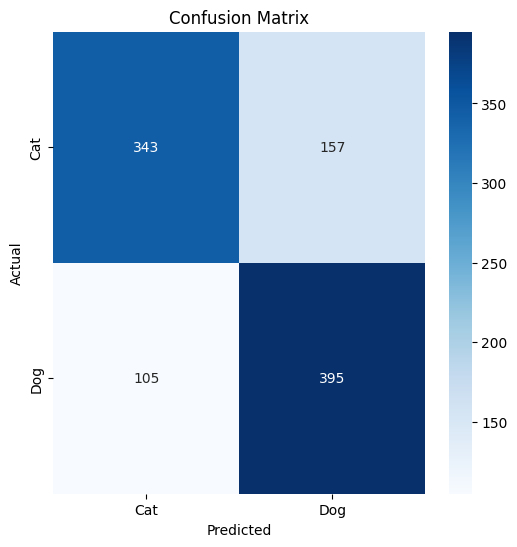

In [ ]:
# ============================================================
# TEST ALEXNET
# ============================================================

print("\nALEXNET TEST RESULTS")

alex_accuracy = evaluate_model(
    alexnet,
    test_loader
)

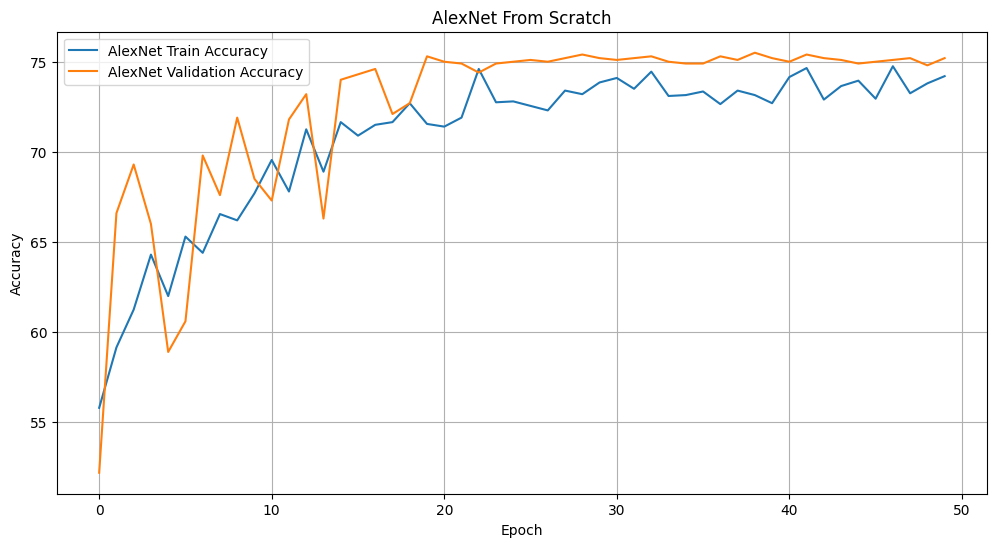

In [ ]:
# ============================================================
# PLOT ACCURACY
# ============================================================

plt.figure(figsize=(12,6))

plt.plot(
    alex_train_acc,
    label='AlexNet Train Accuracy'
)

plt.plot(
    alex_val_acc,
    label='AlexNet Validation Accuracy'
)


plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title(
    "AlexNet From Scratch"
)

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# ============================================================
# FINAL RESULTS
# ============================================================

print("\nFINAL RESULTS")
print("="*50)

print(f"AlexNet Accuracy : {alex_accuracy:.2f}%")


FINAL RESULTS
AlexNet Accuracy : 73.80%


In [ ]:
# ============================================================
# INITIALIZE VGG16
# ============================================================

def initialize_weights(model):

    for m in model.modules():

        if isinstance(m, nn.Conv2d):

            nn.init.kaiming_normal_(m.weight)

        elif isinstance(m, nn.Linear):

            nn.init.xavier_normal_(m.weight)


vgg16 = VGG16Scratch().to(device)
initialize_weights(vgg16)
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    vgg16.parameters(),
    lr=0.00001
)

In [ ]:
# ============================================================
# TRAIN VGG16
# ============================================================

print("\nTRAINING VGG16 FROM SCRATCH")

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.5
)

vgg_train_acc, vgg_val_acc = train_model(

    vgg16,

    train_loader,

    val_loader,

    criterion,

    optimizer,

    scheduler,

    epochs=50
)


TRAINING VGG16 FROM SCRATCH

Epoch 1/50
Loss: 38.5547
Train Accuracy: 53.85%
Validation Accuracy: 61.40%

Epoch 2/50
Loss: 35.2636
Train Accuracy: 55.20%
Validation Accuracy: 63.10%

Epoch 3/50
Loss: 29.7874
Train Accuracy: 58.30%
Validation Accuracy: 65.10%

Epoch 4/50
Loss: 28.8160
Train Accuracy: 57.75%
Validation Accuracy: 62.30%

Epoch 5/50
Loss: 26.2015
Train Accuracy: 60.75%
Validation Accuracy: 66.10%

Epoch 6/50
Loss: 26.6361
Train Accuracy: 59.65%
Validation Accuracy: 66.80%

Epoch 7/50
Loss: 24.7615
Train Accuracy: 60.85%
Validation Accuracy: 65.90%

Epoch 8/50
Loss: 23.5270
Train Accuracy: 62.55%
Validation Accuracy: 66.60%

Epoch 9/50
Loss: 23.8004
Train Accuracy: 62.15%
Validation Accuracy: 68.30%

Epoch 10/50
Loss: 22.4728
Train Accuracy: 63.75%
Validation Accuracy: 66.10%

Epoch 11/50
Loss: 22.2996
Train Accuracy: 64.05%
Validation Accuracy: 66.80%

Epoch 12/50
Loss: 21.6082
Train Accuracy: 65.55%
Validation Accuracy: 68.40%

Epoch 13/50
Loss: 22.4776
Train Accuracy: 6


VGG16 TEST RESULTS

Test Accuracy: 70.20%

Classification Report:

              precision    recall  f1-score   support

         Cat       0.71      0.69      0.70       500
         Dog       0.70      0.71      0.70       500

    accuracy                           0.70      1000
   macro avg       0.70      0.70      0.70      1000
weighted avg       0.70      0.70      0.70      1000



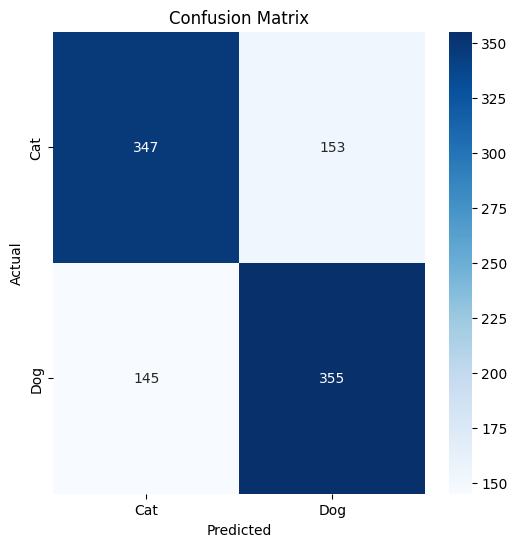

In [ ]:
# ============================================================
# TEST VGG16
# ============================================================

print("\nVGG16 TEST RESULTS")

vgg_accuracy = evaluate_model(
    vgg16,
    test_loader
)

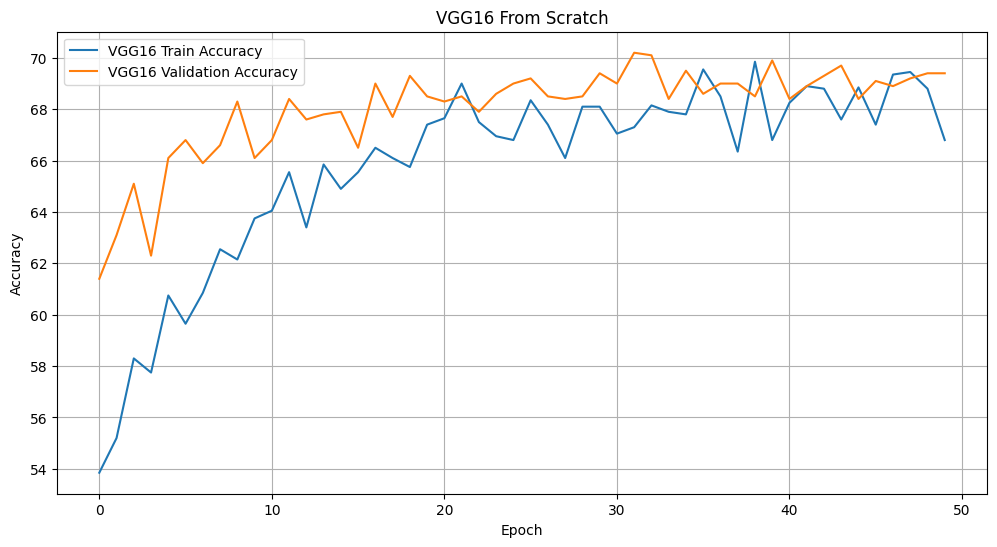

In [ ]:
# ============================================================
# PLOT ACCURACY
# ============================================================

plt.figure(figsize=(12,6))


plt.plot(
    vgg_train_acc,
    label='VGG16 Train Accuracy'
)

plt.plot(
    vgg_val_acc,
    label='VGG16 Validation Accuracy'
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title(
    "VGG16 From Scratch"
)

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# ============================================================
# FINAL RESULTS
# ============================================================

print("\nFINAL RESULTS")
print("="*50)

print(f"VGG16 Accuracy   : {vgg_accuracy:.2f}%")


FINAL RESULTS
VGG16 Accuracy   : 70.20%
